# HOUSE PRICE
Id : Identifiant unique pour chaque enregistrement.

MSSubClass : Type de logement impliqué dans la vente.

MSZoning : Classification générale du zonage de la propriété.

LotArea : Superficie du terrain en pieds carrés.

LotConfig : Configuration du terrain.

Type de bâtiment : Type de logement.

Condition générale : Évaluation globale de l’état de la maison.

Année de construction : Année de construction initiale.

YearRemodAdd : année de rénovation (équivalente à l’année de construction si pas de rénovation).

Extérieur1e : Revêtement extérieur de la maison.

BsmtFinSF2 : Pieds carrés finis de type 2 du sous-sol.

TotalBsmtSF : Surface totale du sous-sol en pieds carrés.

SalePrice : La variable cible que nous cherchons à prédire.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_excel("data/HousePricePrediction.xlsx")
dataset.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [5]:
dataset.shape

(2919, 13)

In [7]:
object_cols = dataset.select_dtypes(include=['object']).columns
print("categorical variables: ", len(object_cols))
int_cols = dataset.select_dtypes(include=['int64']).columns
print("integer variables: ", len(int_cols))
fl_cols = dataset.select_dtypes(include=['float64']).columns
print("floar variables: ", len(fl_cols))

categorical variables:  4
integer variables:  6
floar variables:  3


C:\Users\gb\AppData\Local\Temp\ipykernel_16208\2115732659.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = dataset.select_dtypes(include=['object']).columns


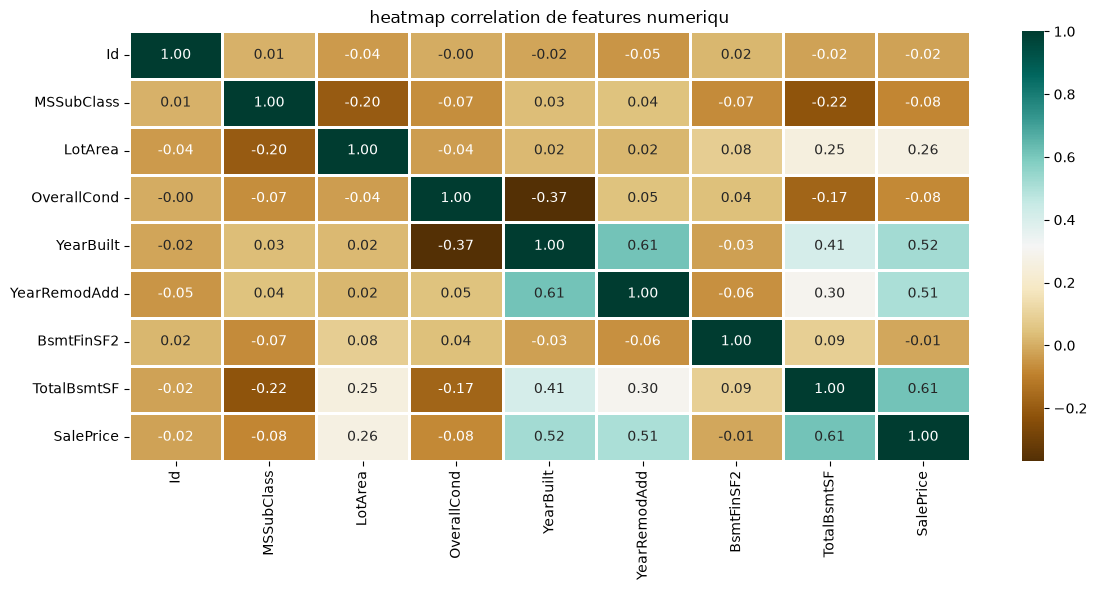

In [10]:
numerical_dataset = dataset.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,6))
sns.heatmap(numerical_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("heatmap correlation de features numeriqu")
plt.tight_layout()

<Axes: title={'center': 'no unique values of categorical features'}, xlabel='None'>

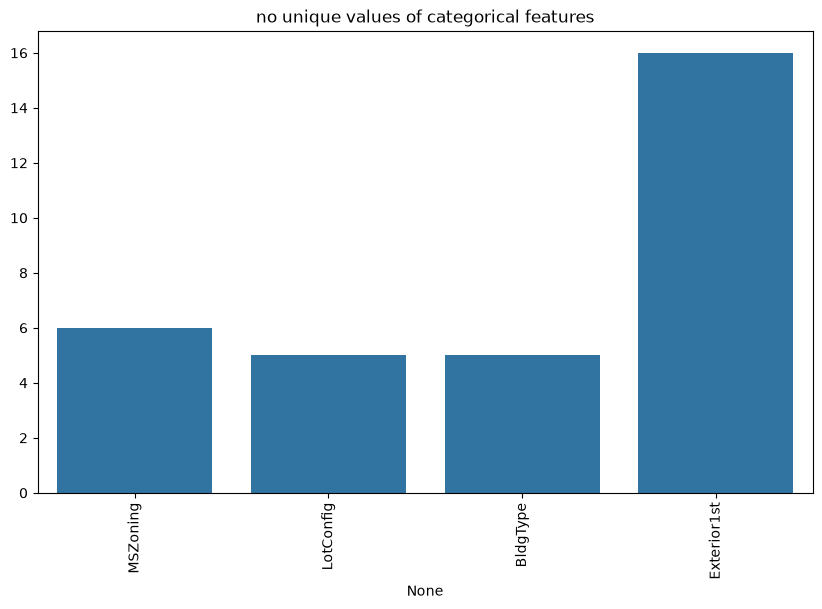

In [11]:
unique_values = []
for col in object_cols:
    unique_values.append(dataset[col].unique().size)
plt.figure(figsize=(10,6))
plt.title("no unique values of categorical features")
plt.xticks(rotation=90)
sns.barplot(x=object_cols, y=unique_values)

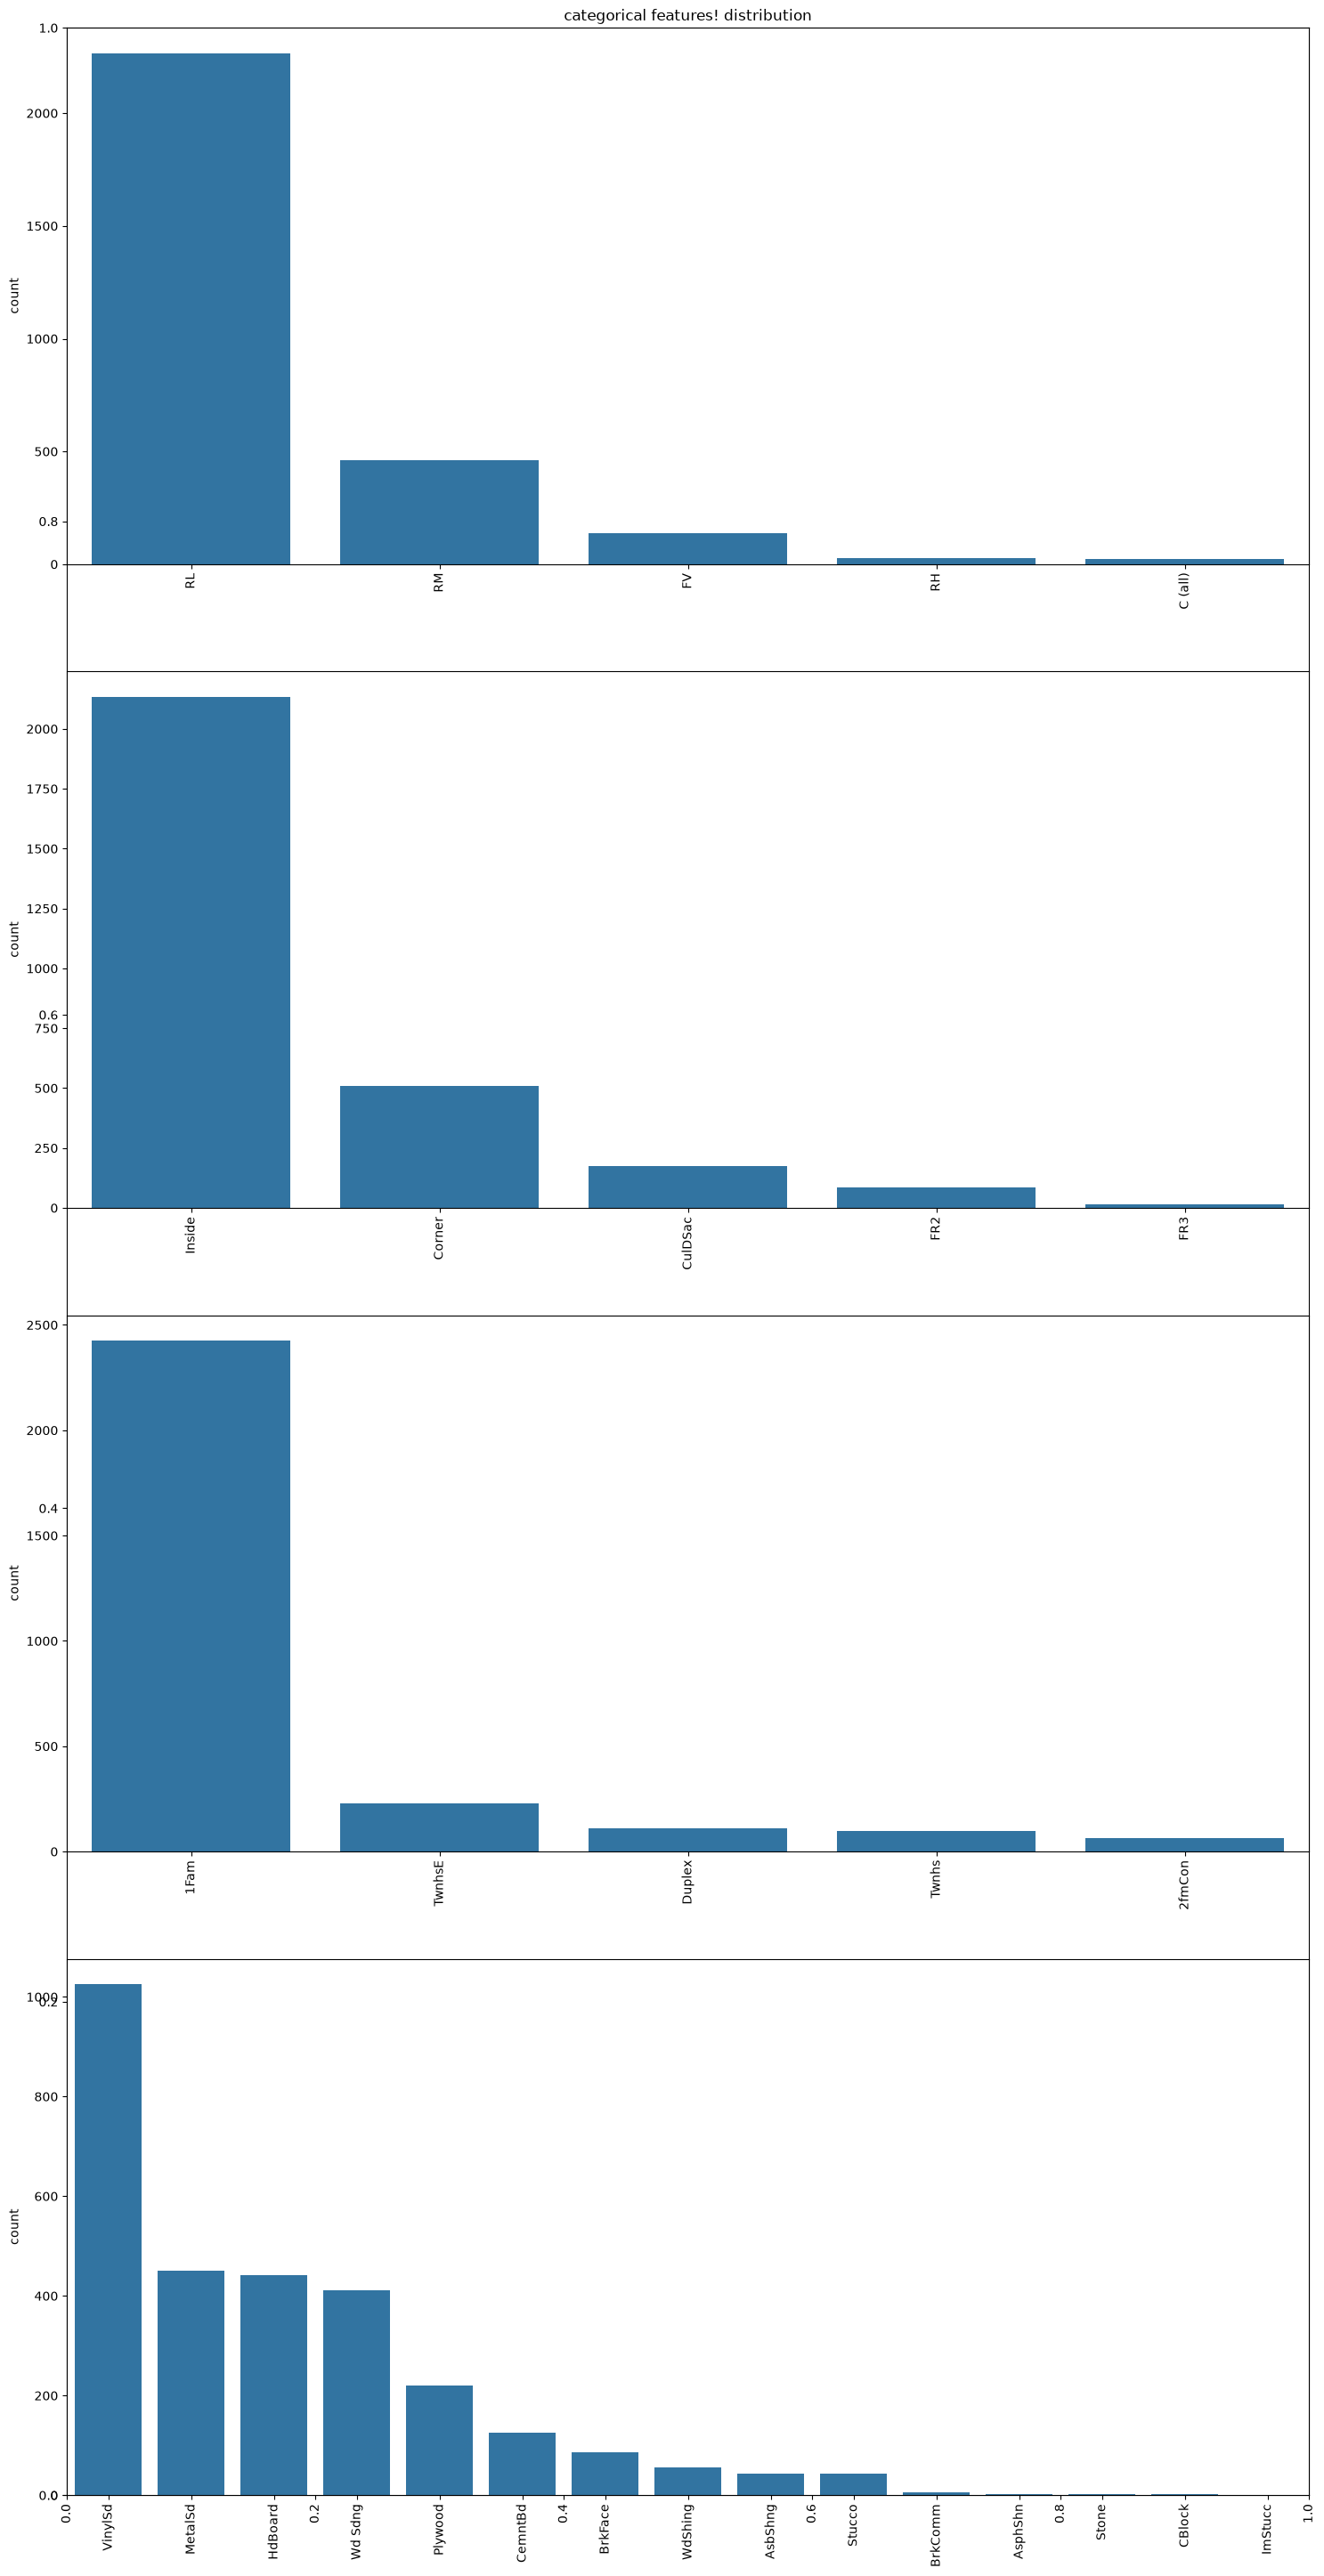

In [15]:
plt.figure(figsize=(18,36))
plt.title('categorical features! distribution')
plt.xticks(rotation=90)
index = 1

for col in object_cols:
    y = dataset[col].value_counts()
    plt.subplot(4,1, index)
    plt.xticks(rotation=90)
    sns.barplot(x=list(y.index), y=y)
    index +=1 

In [16]:
dataset.drop(['Id'],
             axis=1,
             inplace=True)

In [18]:
dataset['SalePrice'] = dataset['SalePrice'].fillna(dataset['SalePrice'].mean())

In [19]:
new_dataset = dataset.dropna()

In [20]:
new_dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [25]:
from sklearn.preprocessing import OneHotEncoder
object_cols = list(new_dataset.select_dtypes(include=['object']).columns)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ', 
      len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


C:\Users\gb\AppData\Local\Temp\ipykernel_16208\3264677973.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = list(new_dataset.select_dtypes(include=['object']).columns)


In [26]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_test, Y_train, Y_vali = train_test_split(
    X,Y, test_size=0.2, random_state=0)

In [31]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model_SVR = svm.SVR()
model_SVR.fit(X_train, Y_train)
Y_pred = model_SVR.predict(X_test)
mean_absolute_percentage_error(Y_vali, Y_pred)

0.1870512931870423

In [32]:
from sklearn.ensemble import RandomForestRegressor
model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_test)

mean_absolute_percentage_error(Y_vali,Y_pred)

0.19066328789473844

In [33]:
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_test)

mean_absolute_percentage_error(Y_vali,Y_pred)

0.187416838415999